# Geavanceerd VKM Aanbevelingssysteem

Welkom bij het geavanceerde aanbevelingssysteem voor VKM-modules. Dit notebook combineert een grondige data-analyse (EDA) met een slim algoritme om je te helpen de perfecte module te vinden.

## Wat doet dit systeem?
In plaats van alleen te zoeken op trefwoorden, "begrijpt" dit systeem de inhoud van de modules. Je kunt zoeken door een beschrijving te geven van wat je wilt leren (in je eigen woorden). Daarnaast kun je filteren op:
-   **Minimaal aantal studiepunten (EC)**
-   **Maximale moeilijkheidsgraad**
-   **Specifieke tags** (onderwerpen)

Het systeem geeft niet alleen een lijst met modules, maar legt ook uit **waarom** een module bij je past.

## Inhoudsopgave
1.  **Data Inladen en Opschonen**: De basis leggen voor onze analyse.
2.  **Exploratieve Data Analyse (EDA)**: Inzichten in het aanbod (studiepunten, moeilijkheid, woordwolken).
3.  **Het Model Trainen**: De computer leren om tekst te begrijpen (TF-IDF).
4.  **Aanbevelingen Krijgen**: Het systeem gebruiken om modules te vinden.

In [17]:
from dataclasses import dataclass
from typing import List, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from sklearn.feature_extraction import text

# Instellingen voor visualisaties
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("libraries geladen.")

libraries geladen.


## 1. Data Inladen en Opschonen

We beginnen met het inladen van de dataset. We zorgen ervoor dat we alle relevante tekstkolommen samenvoegen zodat ons model zoveel mogelijk informatie heeft.

In [18]:
# Data inladen
file_path = 'Opgeschoonde_VKM_datasetv2.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Dataset ingeladen met {len(df)} modules.")
except FileNotFoundError:
    print("Bestand niet gevonden. Controleer het pad.")

# Bekijk de eerste paar regels
df.head(3)

Dataset ingeladen met 211 modules.


,id,name,shortdescription,description,studycredit,location,contact_id,level,learningoutcomes,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,kennismaking met psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,15,den bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,15,den bosch,58,NLQF5,De student toont professioneel gedrag conform ...,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,15,den bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23


### Tekst Opschonen (NLP)
Om de computer de tekst goed te laten begrijpen, moeten we "ruis" verwijderen. Dit zijn woorden die veel voorkomen maar weinig betekenis hebben (stopwoorden), zoals "de", "het", "een", "student". Ook willen we woorden terugbrengen naar hun stam (lemmatization), zodat "lopen" en "loopt" als hetzelfde worden gezien.

In [19]:
# Spacy model laden voor Nederlands
try:
    nlp = spacy.load("nl_core_news_sm", disable=['parser', 'ner'])
except OSError:
    print("Spacy model 'nl_core_news_sm' niet gevonden. We downloaden het nu...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "nl_core_news_sm"])
    nlp = spacy.load("nl_core_news_sm", disable=['parser', 'ner'])

# Uitgebreide lijst met Nederlandse stopwoorden
stopwoorden = [
    'de', 'en', 'van', 'ik', 'te', 'dat', 'die', 'in', 'een', 'hij', 'het', 'niet', 
    'zijn', 'is', 'was', 'op', 'aan', 'met', 'als', 'voor', 'had', 'er', 'maar', 
    'om', 'hem', 'dan', 'zou', 'of', 'wat', 'mijn', 'mens', 'dit', 'zo', 'door', 
    'over', 'ze', 'zich', 'bij', 'ook', 'tot', 'je', 'mij', 'uit', 'der', 'daar', 
    'haar', 'naar', 'als', 'bij', 'ons', 'u', 'deze', 'hoe', 'and', 'the', 'to', 'with', 
    'on', 'for', 'is', 'in', 'that', 'it', 'of', 'as', 'this', 'by', 'at', 'from', 'an', 
    'be', 'are', 'or', 'not', 'but', 'all', 'your', 'we', 'they', 'his', 'have', 'has', 'my', 
    'so', 'if', 'there', 'what', 'about', 'who', 'you', 'nog', 'kennis', 'studenten', 'module', 'students', 'gaan', 'waarbij', 'eerste',
    'worden','leren', 'maken', 'doen', 'kunnen', 'willen', 'zullen', 'moeten', 
    'gaan', 'volgen', 'gebruiken', 'leren', 'analyseren', 'ontwikkelen',
    'toepassen', 'bieden', 'kijken', 'zien', 'staan', 'vinden',
    'module', 'minor', 'student', 'studenten', 'project', 'opdracht', 
    'werk', 'praktijk', 'onderzoek', 'hbo', 'avans', 'opleiding',
    'groep', 'individueel', 'les', 'semester', 'punten', 'ec',
    'volgens', 'hun', 'slag', 'waarbij', 'elkaar', 'eigen', 'binnen',
    'tijdens', 'waarin', 'diverse', 'verschillende', 'centraal', 'ntb', 'basis', 'leren'
    'ontwikkel', 'ontwikkelen', 'ontwikkeld', 'ontwikkeld'
    'maken', 'maak', 'maakt', 'maken'
    'leren', 'leren', 'leren', 'leren', 'Leren', 'lEren'
]

# Stopwoorden toevoegen aan Spacy
for woord in stopwoorden:
    nlp.vocab[woord].is_stop = True

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    doc = nlp(text)
    # Lemmatize en verwijder stopwoorden en leestekens
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha and len(token.text) > 2]
    return " ".join(tokens)

# We combineren de belangrijkste kolommen tot één tekstveld
df['combined_text'] = df['name'].fillna('') + " " + df['description'].fillna('') + " " + df['learningoutcomes'].fillna('') + " " + df['module_tags'].fillna('')

print("Bezig met tekst opschonen... (dit kan even duren)")
df['processed_text'] = df['combined_text'].apply(clean_text)
print("Tekst opgeschoond!")

Bezig met tekst opschonen... (dit kan even duren)
Tekst opgeschoond!


## 2. Exploratieve Data Analyse (EDA)

Laten we kijken wat voor modules we in huis hebben. We kijken naar de verdeling van studiepunten, moeilijkheidsgraad en de meest voorkomende woorden.

C:\Users\yazan\AppData\Local\Temp\ipykernel_9936\4145280714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='studycredit', palette='viridis')


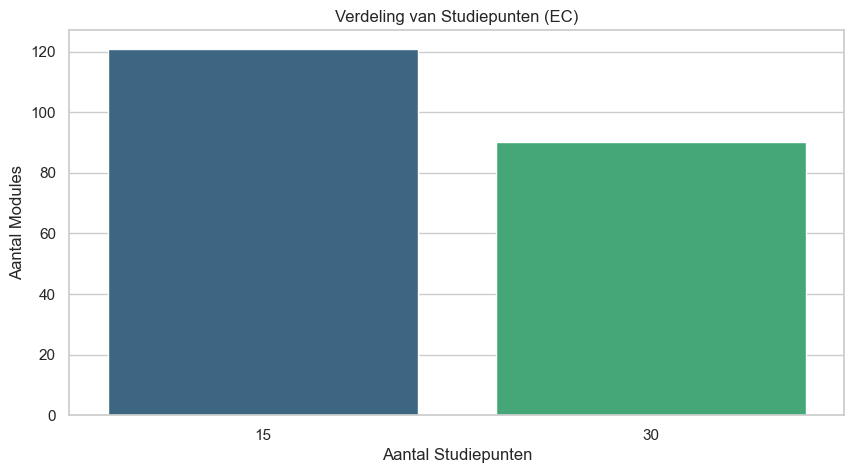

In [20]:
# Verdeling Studiepunten
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='studycredit', palette='viridis')
plt.title('Verdeling van Studiepunten (EC)')
plt.xlabel('Aantal Studiepunten')
plt.ylabel('Aantal Modules')
plt.show()

# conclusies:
- we zien hier dat er 120 vkms met 15 studiepunten zijn
- we zien hier dat er 90 vkms met 30 studiepunten zijn
- dus we hebben ongeveer 210 vkms in totaal waarvan de meeste 15 studiepunten hebben

# 

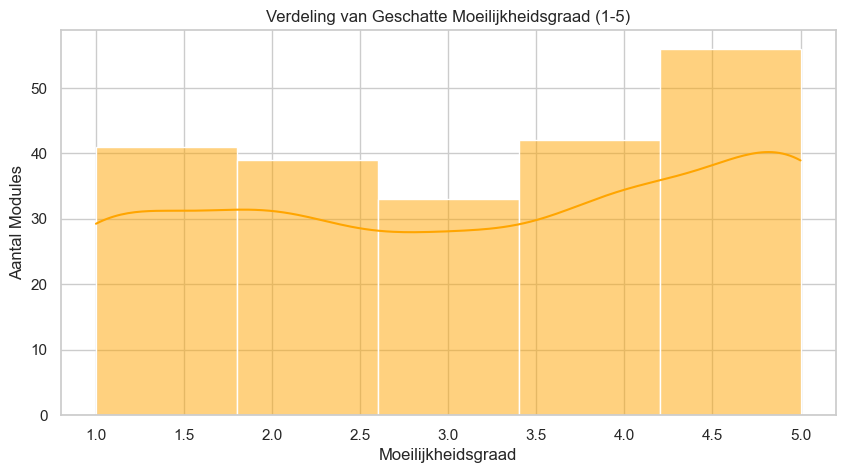

In [21]:
# Verdeling Moeilijkheidsgraad
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='estimated_difficulty', bins=5, kde=True, color='orange')
plt.title('Verdeling van Geschatte Moeilijkheidsgraad (1-5)')
plt.xlabel('Moeilijkheidsgraad')
plt.ylabel('Aantal Modules')
plt.show()

# conclusie
- De moeilijkheidsgraad is niet gelijk verdeeld, er zitten juist veel modules rond niveau 1, 2 en vooral 5.
- Niveau 3 heeft opvallend weinig modules.
- Niveau 5 komt het meest voor, dus er zijn relatief veel moeilijke modules.

De trendlijn laat een lichte stijging naar de hogere moeilijkheidsniveaus zien, wat betekent dat het aanbod gemiddeld iets naar moeilijkere modules verschuift.

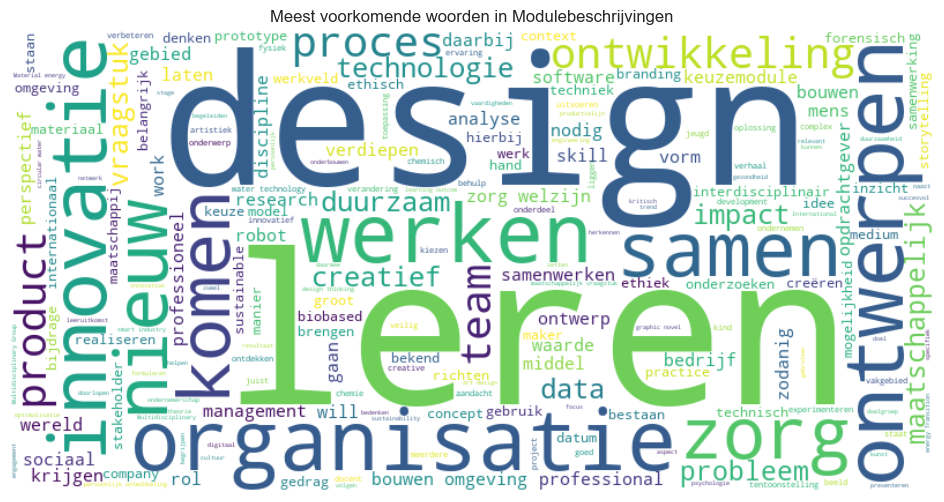

In [22]:
# WordCloud
text_content = " ".join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_content)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Meest voorkomende woorden in Modulebeschrijvingen')
plt.show()

# conclusies: 

- De meest dominante thema's in de modulebeschrijvingen gaan over ontwerpen, leren, samenwerken, innovatie en organisatie.

- Er is veel focus op designgerichte en praktijkgerichte modules.

- Woorden zoals zorg, technologie, software en creatief komen ook vaak terug, wat wijst op brede domeinen (zorg, tech, creativiteit).

- Het algemene taaldomein draait vooral om leren door te doen, samenwerken en nieuwe oplossingen creëren.

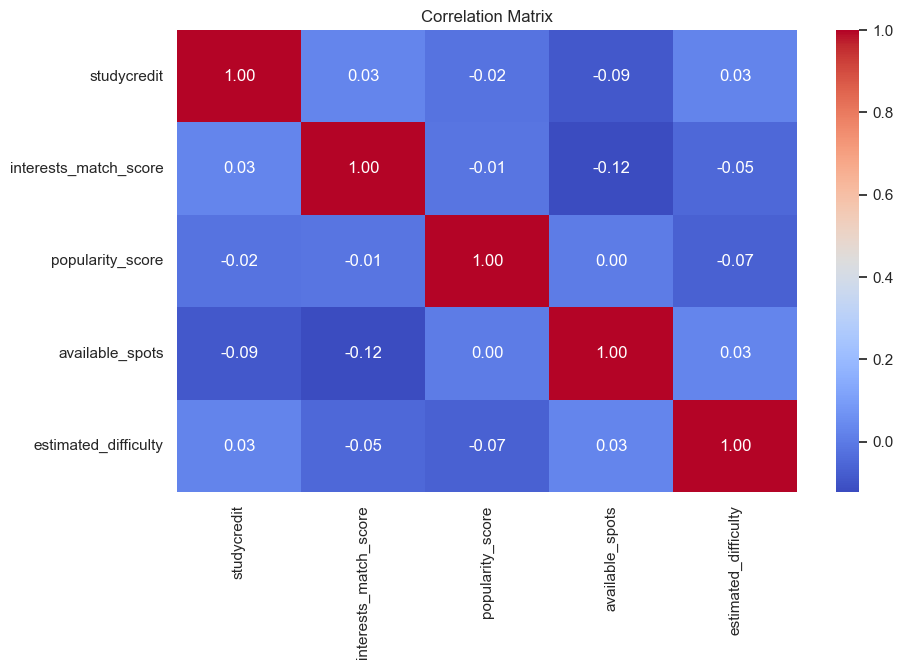

In [23]:
plt.figure(figsize=(10, 6))
numeric_cols = ['studycredit', 'interests_match_score', 'popularity_score', 'available_spots', 'estimated_difficulty']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# conclusies

- Het is opvallend dat er geen correlatie te vinden is tussen bijvoorbeeld 'estimated difficulty', en 'popularity_score'. 

- De aanname dat studenten kiezen voor makkelijke studiepunten is dus niet waar in dit geval.

- Moeilijkheid hoeft dus niet zwaar te wegen als een negatieve factor in het aanbeveling systeem.

- dus is het waarschijnlijk dat de aanbevelingssysteem beter zou kunnen werken als de moeilijkheid niet zwaar te wegen als een negatieve factor en we hier niet teveel op mioeten letten.

C:\Users\yazan\AppData\Local\Temp\ipykernel_9936\4128307496.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(tags), palette='viridis')


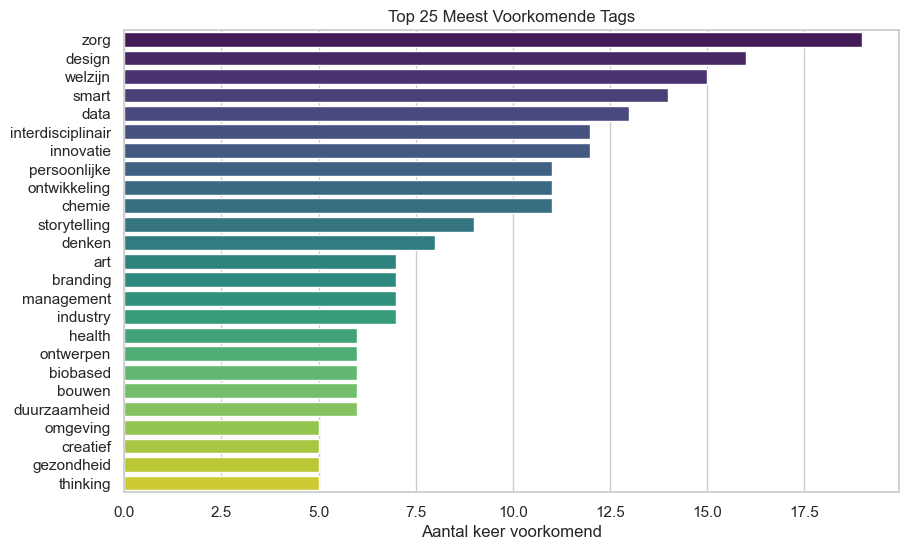

In [24]:
from collections import Counter
import ast
def parse_tags(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []
        
df['module_tags_list'] = df['module_tags'].apply(parse_tags)


alle_tags = [
    tag.strip().lower()
    for tags in df["module_tags_list"]
    for tag in tags
    if tag.strip().lower() not in stopwoorden
]
top_25_tags = Counter(alle_tags).most_common(25)

tags, counts = zip(*top_25_tags)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(tags), palette='viridis')
plt.title('Top 25 Meest Voorkomende Tags')
plt.xlabel('Aantal keer voorkomend')
plt.show()

# conclusies:
- stopwoorden weg gehaald
-  zorg is meest voorkomend (18x)
- module tags meenemen in aanbevelingssysteem zal een goede keuze worden

# PCA 
# Content Analyse & Dimensionality Reduction

We gaan hier proberen te kijken naar of de data groepen vormt, en patronen laat zien die we eerder niet konden waarnemen. 

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.73)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f'Aantal componenten na PCA: {pca.n_components_}')

NameError: name 'tfidf_matrix' is not defined

# t-sne

In [ ]:
from sklearn.manifold import TSNE
X_for_tsne = pca_result

# 2. Run t-SNE
print("Calculating t-SNE... this may take a moment.")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
tsne_result = tsne.fit_transform(X_for_tsne)

df['tsne_x'] = tsne_result[:, 0]
df['tsne_y'] = tsne_result[:, 1]

print("t-SNE columns added to vkm!")

Calculating t-SNE... this may take a moment.
t-SNE columns added to vkm!


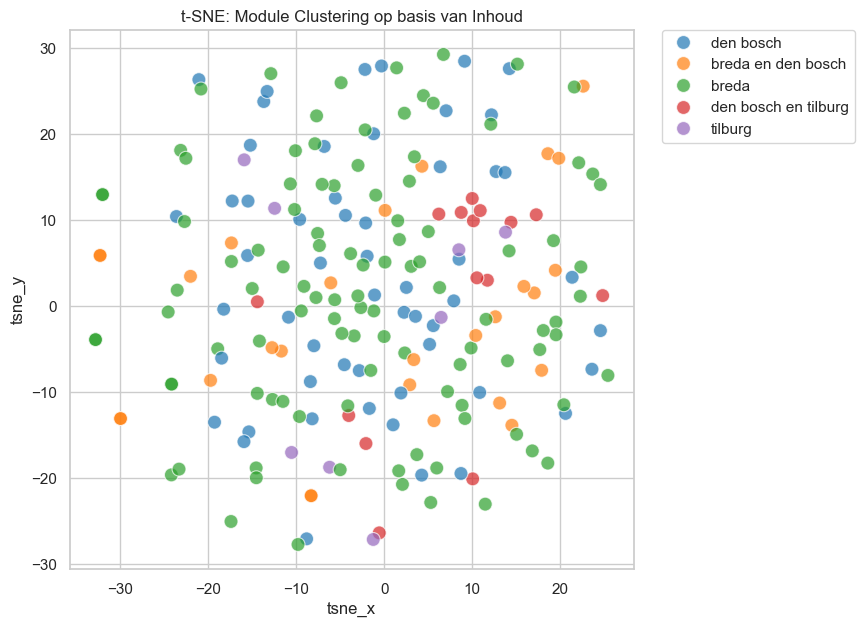

In [ ]:
# We kleuren de punten in op basis van 'Location' (of je kunt later Clusteren)
plt.figure(figsize=(16, 7))

# Plot 1: t-SNE
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df, x='tsne_x', y='tsne_y', 
    hue='location',
    palette='tab10', s=100, alpha=0.7
)
plt.title('t-SNE: Module Clustering op basis van Inhoud')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

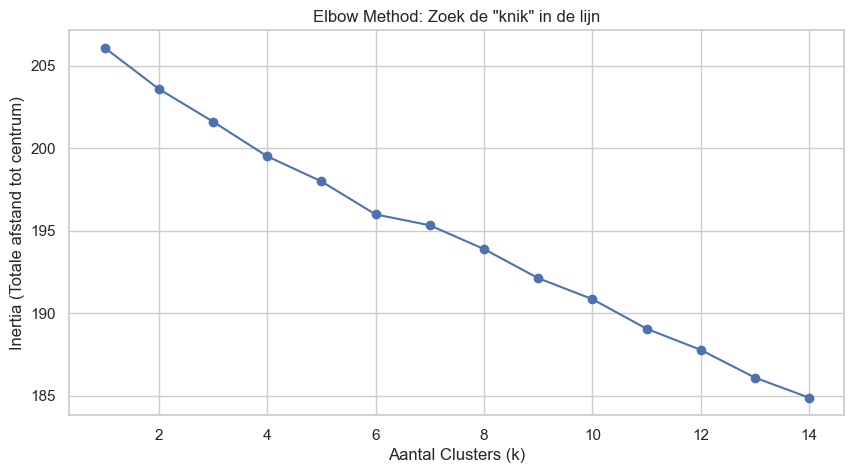

In [ ]:
inertia = []
K_range = range(1, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Aantal Clusters (k)')
plt.ylabel('Inertia (Totale afstand tot centrum)')
plt.title('Elbow Method: Zoek de "knik" in de lijn')
plt.grid(True)
plt.show()

Het is wat moeilijk te zien, maar we denken dat de elbow rond 5 of 6 zit. We nemen 6 als aantal clusters

--- DIT ZIJN DE ONDERWERPEN PER KLEUR ---
Cluster 0: bouwen, omgeving, duurzaam, interdisciplinair, maatschappelijk
Cluster 1: water, research, multidisciplinary, will, transition
Cluster 2: zorg, design, welzijn, product, ontwerpen
Cluster 3: data, chemie, bedrijf, datum, leren
Cluster 4: innovatie, art, formuleren, organisatie, sociaal
Cluster 5: samenleving, welzijn, zorg, leefstijl, jeugd


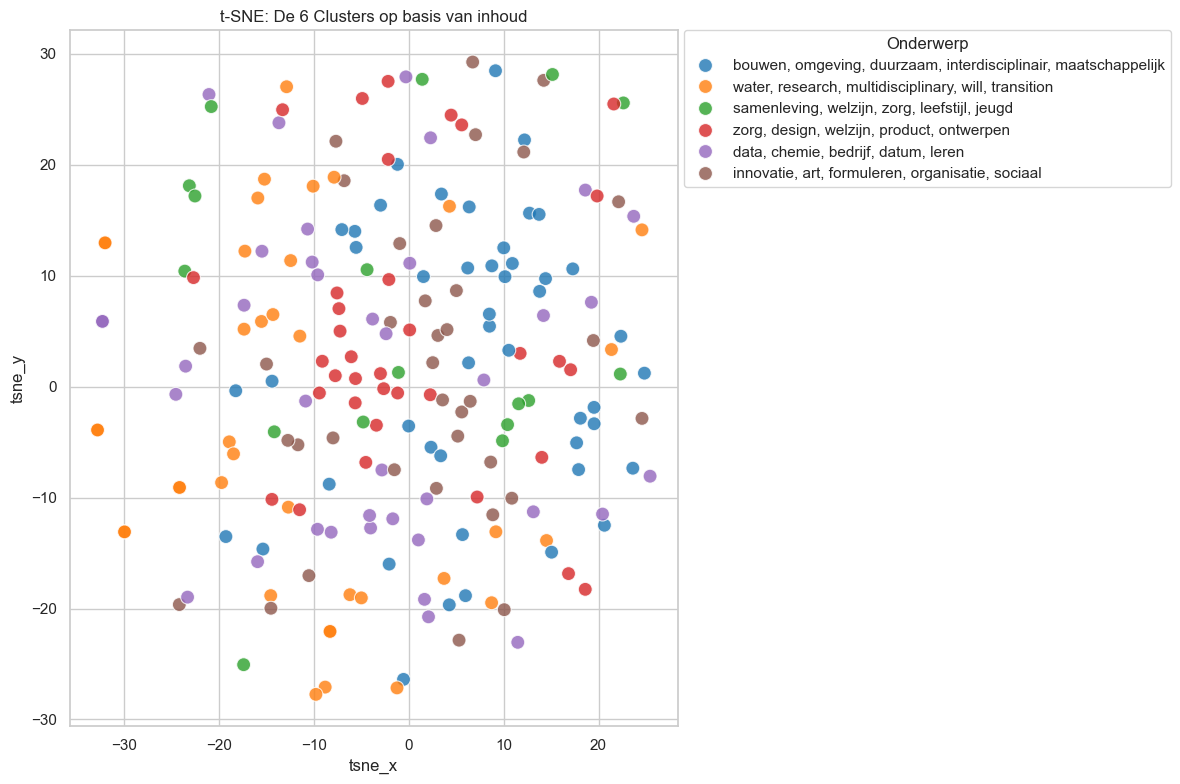

In [ ]:
from sklearn.cluster import KMeans
amount_of_clusters = 6
kmeans = KMeans(n_clusters=amount_of_clusters, random_state=42)

# Laat het model NU pas rekenen
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

print("--- DIT ZIJN DE ONDERWERPEN PER KLEUR ---")
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_labels = {} 

for i in range(amount_of_clusters):
    # Pak de top 5 woorden
    top_words = [terms[ind] for ind in order_centroids[i, :5]]
    
    # Maak de naam
    name = ", ".join(top_words)
    cluster_labels[i] = name
    
    print(f"Cluster {i}: {name}")

# Voeg de namen toe aan de dataframe
df['cluster_name'] = df['cluster'].map(cluster_labels)

# Plot 2: t-SNE met KMeans Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='tsne_x', 
    y='tsne_y', 
    hue='cluster_name',  # Gebruik de NAMEN in de legenda
    palette='tab10',     # Goed contrast
    s=100,
    alpha=0.8
)
plt.title(f't-SNE: De {amount_of_clusters} Clusters op basis van inhoud')
# Legenda buiten de plot zetten zodat hij niet over je punten heen valt
plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0., title="Onderwerp")
plt.tight_layout()
plt.show()

De kleuren liggen hier bijna volledig door elkaar, De enige twee duidelijke clusters zijn Rood en Groen. 

Maar helaas is het vooral onoverzichtelijk en door elkaar. Vooral Oranje, Blauw en Grijs is geen patroon in te vinden. 

## UMAP (Uniform Manifold Approximation and Projection)
Naast PCA en t-SNE gebruiken we ook UMAP voor dimensionaliteitsreductie. UMAP is vaak sneller dan t-SNE en bewaart beter de globale structuur van de data, terwijl het ook lokale clusters goed weergeeft.

We passen UMAP toe op dezelfde data als t-SNE (de PCA-resultaten of de TF-IDF matrix) en kleuren de plot opnieuw op basis van het 'level' van de modules.

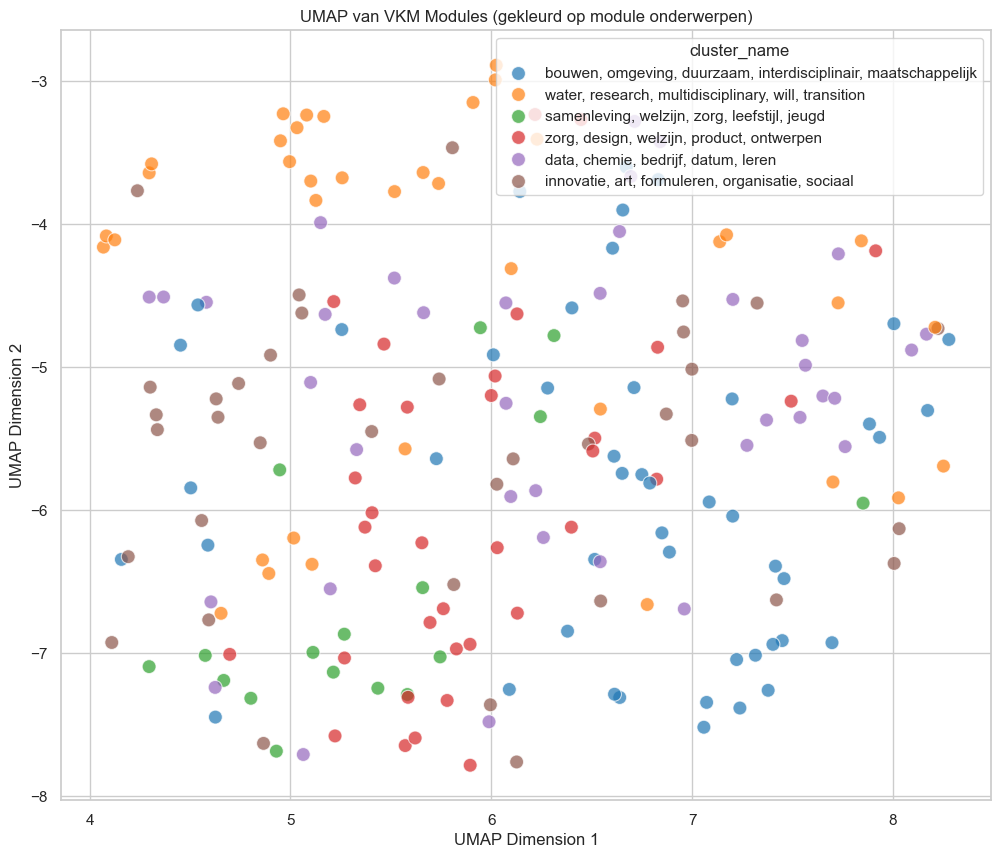

In [ ]:
import umap

X_for_umap = pca_result 

reducer = umap.UMAP(n_components=2)
umap_result = reducer.fit_transform(X_for_umap)

df['umap_x'] = umap_result[:, 0]
df['umap_y'] = umap_result[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(x='umap_x', y='umap_y', hue='cluster_name', data=df, palette='tab10', s=100, alpha=0.7)
plt.title('UMAP van VKM Modules (gekleurd op module onderwerpen)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)
plt.show()

We zien hier veel overlap, vooral in het midden, wat waarschijnlijk komt omdat onderwerpen zoals technologie en innovatie bij vele modules passen tegenwoordig.

De Rode cluster met Zorg en Welzijn is wel duidelijk te onderscheiden van de anderen, waarschijnlijk omdat er veel woorden worden gebruikt die alleen in zulk soort opleidingen kunnnen zitten.

De Rode cluster met art, research, kunst etc. is ook wel te onderscheiden, aangezien die vooral links onder van het middenpunt zit. Waarschijnlijk zijn ze niet dicht op elkaar geclusterd omdat Research erg breed is en vaak bij module beschrijvingen word gebruikt.

De clustering werkt wel voor een paar specifieke onderwerpen, maar slecht voor moderne, creatieve of technologie bevattende modules, omdat dat tegenwoordig vaak tenminste een klein onderdeel is van elke module.

#### Over het aanbevelingssysteem
Een student die "zorg" leuk vind kan je veilig andere Groene modules aanraden, maar als een student een Oranje module leuk vind, wordt het riskant om andere Oranje aan te bevelen, omdat deze heel breed liggen en geen echte cluster vormen.

Dus we moeten niet enkel op NLP vertrouwen, omdat dit in onze dataset niet altijd betrouwbaar genoeg is.



# Volledige Conclusie:

Op basis van de uitgevoerde Exploratory Data Analysis (EDA) en de Content Analyse kunnen we een aantal inzichten maken voor het ontwerp van het aanbevelingssysteem. De data laat zien dat filteren op 'leuke vakken' niet genoeg is; we moeten rekening houden met locatie, beschikbaarheid en de nadelen van tekstuele analyse.

1. ### Studenten kiezen makkelijke modules voor 'makkelijke studiepunten' - Niet Waar
Het is opvallend dat er geen correlatie is gevonden tussen de geschatte moeilijkheid (estimated_difficulty) en de populariteit van een module. De aanname dat studenten kiezen voor makkelijke modules blijkt onjuist.

Dus: We hoeven moeilijkheidsgraad niet zwaar te wegen als negatieve factor. Het is niet erg belangrijk voor de keuze van de student.

2. ### Locatie en de limieten van een harde filter
Er is een sterke scheefgroei in het aanbod per locatie. Het overgrote deel van de modules vindt plaats in Breda en Den Bosch, waarbij modules in Den Bosch gemiddeld zelfs de hoogste populariteitsscores behalen. Tilburg blijft hierin achter.

Dus: Als we studenten laten filteren op locatie, missen ze soms wel meer dan de helft van het relevante aanbod. In plaats van harde filters, moeten we het systeem zo inrichten dat het sorteert op locatie, maar andere steden wel zichtbaar houdt (bijvoorbeeld met een label "Aanbevolen in Den Bosch"). We moeten studenten nudgen om ook te kijken naar de inhoud, en niet de locatie te priorisern.

3. ### Mismatch in Vraag en Aanbod
De scatterplot tussen available_spots en popularity_score toont geen correlatie, wat wijst op een mismatch in de planning. Ongeveer 25% van de modules is populair met weinig plek, en ook ongeveer 25% is niet populair maar heeft veel plek.

Hoog populair / Weinig plek: Dit zorgt voor teleurstelling en uitloting. Het systeem moet hier proactief op acteren door een waarschuwing te tonen ("Let op: kans op uitloting is groot") en direct goeie, minder volle alternatieven aan te bieden.

Laag populair / Veel plek: Dit leidt tot inefficiëntie en studenten die 'verplicht' moeten aansluiten bij impopulaire vakken. Deze modules moeten wellicht anders gepromoot worden of inhoudelijk geanalyseerd worden op hun lage score.

Daarnaast laat dit zien dat er niet goed is nagedacht over de verdeling, want nu krijgen we ontevreden studenten, en lege klaslokalen bij de minder populaire met veel plek. 

4. ### Woordgebruik en Trends
Uit de module tag-analyse blijkt dat studenten erg kijken naar moderne vaktaal. Termen als Technologie, Smart en Innovation scoren hoog, terwijl traditionele termen als Techniek, Analyse en Kunst laag scoren.

Dus: Bij het matchen van interesses moeten we rekening houden met synoniemen. Een student die zoekt op 'Techniek' moet wellicht gematcht worden aan 'Technologie' of 'Smart', omdat daar de populairdere inhoud zit.

5. ### Beperkingen van NLP en Clustering
De K-Means clustering en t-SNE/UMAP visualisaties laten zien dat onze dataset slechts gedeeltelijk te clusteren is op tekst.

Duidelijke clusters: De domeinen "Zorg & Welzijn" en in mindere mate "Kunst & Research" zijn goed te onderscheiden. Hier werkt content-based filtering betrouwbaar.

Het geruis in het midden: Een groot deel van de modules (Business, Innovatie, Technologie) vertoont veel overlap en vormt geen duidelijke clusters. Dit komt waarschijnlijk doordat deze termen tegenwoordig in bijna elke modulebeschrijving voorkomen.

6. ## Eindoordeel voor het Product
We kunnen niet bouwen op één enkele pijler. Een betrouwbaar aanbevelingssysteem voor deze dataset moet een hybride aanpak hanteren:

Content-based filtering is veilig voor specifieke niches (zoals Zorg), maar riskant voor brede termen (zoals Innovatie).

Nadenken over de capaciteit van modules is belangrijk om teleurstelling over uitloting te voorkomen.

Locatie-nuding (waar we wel transparant in moeten zijn) is nodig om het volledige potentieel van het aanbod in Den Bosch en Breda te benutten.

Het algoritme moet dus niet alleen kijken naar wat de student leuk vindt, maar ook de haalbaarheid (plek en locatie) zwaar meewegen in de uiteindelijke ranking.

# Het Model Trainen (TF-IDF)

We gebruiken TF-IDF (Term Frequency-Inverse Document Frequency) om de tekst om te zetten in getallen. Dit algoritme geeft gewicht aan woorden die uniek zijn voor een module, en minder gewicht aan woorden die overal voorkomen.

In [ ]:
# TF-IDF Vectorizer initialiseren
tfidf = TfidfVectorizer()

# De matrix maken
tfidf_matrix = tfidf.fit_transform(df['processed_text'])

print(f"TF-IDF Matrix vorm: {tfidf_matrix.shape} (Modules, Unieke Woorden)")

TF-IDF Matrix vorm: (211, 3419) (Modules, Unieke Woorden)


## Aanbevelingen Krijgen

Hier bouwen we de functie die jouw input vertaalt naar concrete aanbevelingen. 

**Hoe werkt het?**
1.  We filteren eerst op je harde eisen (studiepunten, moeilijkheid).
2.  We berekenen hoe goed jouw zoektekst past bij de overgebleven modules (Cosine Similarity).
3.  We geven de beste matches terug met een uitleg.

In [ ]:
@dataclass
class CandidateProfile:
    interests_text: str
    preferred_location: Optional[str] = None
    min_studycredits: Optional[float] = None
    max_difficulty: Optional[float] = None
    moduletags_include: Optional[List[str]] = None


In [ ]:
def geef_aanbeveling(profile: CandidateProfile, weights: dict = None, k=5):
    # Standaard gewichten als deze niet zijn opgegeven
    if weights is None:
        weights = {
            'text_similarity': 1.0,  # Basis gewicht voor inhoudelijke match
            'location': 0.5,         # Bonus voor juiste locatie (belangrijk!)
            'tags': 0.3,             # Bonus per matchende tag
            'difficulty': 0.2        # Strafpunten per punt moeilijkheid boven limiet
        }
    
    # 1. Filteren (Harde eisen)
    # We houden studiepunten als harde eis omdat dit vaak administratief noodzakelijk is.
    filtered_df = df.copy()
    if profile.min_studycredits is not None:
        filtered_df = filtered_df[filtered_df['studycredit'] >= profile.min_studycredits]
        
    if len(filtered_df) == 0:
        return "Geen modules gevonden die aan de harde eis voor studiepunten voldoen."

    # 2. Bereken Scores
    
    # A. Tekstuele Match (TF-IDF)
    clean_query = clean_text(profile.interests_text)
    query_vec = tfidf.transform([clean_query])
    subset_indices = filtered_df.index
    subset_tfidf = tfidf_matrix[subset_indices]
    similarities = cosine_similarity(query_vec, subset_tfidf).flatten()
    
    # B. Bereken totale score per module
    results = []
    
    for idx, (original_idx, row) in enumerate(filtered_df.iterrows()):
        # Basis score: Tekst similarity
        text_score = similarities[idx]
        final_score = text_score * weights.get('text_similarity', 1.0)
        
        reasons = []
        if text_score > 0.15:
            reasons.append(f"Inhoudelijk goede match ({text_score * 100:.2f}%).")
        
        # Locatie Bonus
        loc_bonus = 0
        if profile.preferred_location and pd.notna(row['location']):
            if profile.preferred_location.lower() in str(row['location']).lower():
                loc_bonus = weights.get('location', 0.5)
                reasons.append(f"Locatie match ({row['location']}).")
            else:
                # Geen straf, maar wel vermelden in redenatie als het anders is
                # reasons.append(f"Andere locatie ({row['location']}).")
                pass
        final_score += loc_bonus
        
        # Tag Bonus
        tag_bonus = 0
        if profile.moduletags_include and pd.notna(row['module_tags']):
            # Tags zijn string representatie van lijst
            row_tags = str(row['module_tags']).lower()
            matching_tags = [tag for tag in profile.moduletags_include if tag.lower() in row_tags]
            if matching_tags:
                # Bonus per tag
                tag_bonus = len(matching_tags) * weights.get('tags', 0.3)
                reasons.append(f"Tags matchen: {', '.join(matching_tags)}.")
        final_score += tag_bonus
        
        # Moeilijkheid Penalty
        diff_penalty = 0
        if profile.max_difficulty is not None and pd.notna(row['estimated_difficulty']):
            diff = float(row['estimated_difficulty'])
            if diff > profile.max_difficulty:
                diff_diff = diff - profile.max_difficulty
                diff_penalty = diff_diff * weights.get('difficulty', 0.2)
                reasons.append(f"Let op: Iets moeilijker ({diff}) dan gewenst ({profile.max_difficulty}).")
        final_score -= diff_penalty
        
        # Opslaan
        results.append({
            'Module': row['name'],
            'Locatie': row['location'],
            'Score': final_score,
            'EC': row['studycredit'],
            'Moeilijkheid': row['estimated_difficulty'],
            'Redenering': " ".join(reasons) if reasons else "Match op basis van algemene criteria."
        })
    
  # 3. Sorteren, normaliseren naar percentage en Top K
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        # Bepaal max en min score in deze aanbevelingsronde
        max_score = results_df['Score'].max()
        min_score = results_df['Score'].min()

        if max_score > min_score:
            # Min-max normalisatie naar 0–100%
            results_df['Match'] = (
                (results_df['Score'] - min_score) / (max_score - min_score) * 100
            )
        else:
            # Alle scores zijn gelijk, iedereen bv. 100%
            results_df['Match'] = 100.0

        # Mooier maken
        results_df['Match'] = results_df['Match'].round(1)

        # Sorteren op beste match
        results_df = results_df.sort_values(by='Match', ascending=False).head(k)

    return results_df


NameError: name 'CandidateProfile' is not defined

## Interactie Voorbeeld
Hieronder kun je het systeem testen. Pas de variabelen aan om te zien wat er gebeurt.

In [ ]:
#optioneel: custom weights door studenten laten gevne (???!)
mijn_gewichten = {
    'text_similarity': 1.0,  # Hoe belangrijk is de tekstmatch?
    'location': 0.8,         # Hoge bonus voor locatie (zoals gevraagd)
    'tags': 0.3,             # Bonus per tag
    'difficulty': 0.1        # Lage straf voor moeilijkheid
}

profiel = CandidateProfile(
    interests_text="Ik wil leren over data science, python en machine learning.",
    preferred_location="Breda", 
    min_studycredits=15,
    max_difficulty=5,
    moduletags_include=['data', 'python', 'machine learning', 'data science', 'AI']
)
pd.set_option("display.max_colwidth", None)


print("Zoeken naar aanbevelingen voor profiel:")
print(profiel)
print("-"*50)

aanbevelingen = geef_aanbeveling(profiel)
aanbevelingen

Zoeken naar aanbevelingen voor profiel:
CandidateProfile(interests_text='Ik wil leren over data science, python en machine learning.', preferred_location='Breda', min_studycredits=15, max_difficulty=5, moduletags_include=['data', 'python', 'machine learning', 'data science', 'AI'])
--------------------------------------------------


,Module,Locatie,Score,EC,Moeilijkheid,Redenering
130,datagedreven besluitvorming met ai,breda,1.701198,15,4,"Inhoudelijk goede match (30.12%). Locatie match (breda). Tags matchen: data, python, AI."
171,molecular modeling & data-driven analysis,breda,1.564454,30,1,"Inhoudelijk goede match (16.45%). Locatie match (breda). Tags matchen: data, python, AI."
167,forensische chemie,breda en den bosch,0.939082,15,5,Locatie match (breda en den bosch). Tags matchen: data.
146,smart industry & internet of things,breda,0.902066,30,3,Locatie match (breda). Tags matchen: data.
173,sustainable supply chain,breda,0.837501,15,4,Locatie match (breda). Tags matchen: AI.


In [ ]:
# exporteren naar pkl 